# Naive Bayes

**UWE Bristol · Introduction to Machine Learning**

This notebook walks through one classification model from start to finish: **Naive Bayes**.

You will see:

1. how the model works, in plain language;
2. how to load, explore and prepare a dataset (pre-processing);
3. why we split the data into a training set and a test set;
4. how to train (fit) the model and make predictions;
5. how to measure performance with accuracy, a confusion matrix, precision, recall, F1 and a ROC curve;
6. how to visualise what the model has learned;
7. what happens when you change the model's settings.

No previous experience with the model is assumed. Run each cell in order with **Shift + Enter**, and
read the text above each cell before you run it.

## 1. How Naive Bayes works

### The idea

Naive Bayes is a **probability** model. For each new example it asks two questions for every class:

1. **How common is this class in general?** This is called the **prior**. In our data, benign tumours
   are more common than malignant ones.
2. **How likely are these particular measurements if the example belongs to this class?** This is
   called the **likelihood**.

It multiplies these together for each class and predicts the class with the bigger result. This way of
combining evidence comes from **Bayes' theorem**, a rule from probability named after Thomas Bayes.

### A worked example with emails

Naive Bayes is famous for spam filtering, so here is a small made-up example. Out of 100 emails:

- 30 are spam, so the prior probability of spam is 0.30 and of a normal email is 0.70;
- the word "prize" appears in 12 of the 30 spam emails (40%), but only 1 of the 70 normal ones (about 1.4%).

A new email contains the word "prize". Naive Bayes compares:

- spam: 0.30 × 0.40 = 0.120
- normal: 0.70 × 0.014 = 0.010

Scaling these so they add up to 1, the probability that the email is spam is 0.120 / 0.130 ≈ **0.92**.
Even though spam is less common overall, the word "prize" is such strong evidence that the email is
very likely to be spam.

### Why "naive"?

With many features (many words, or 30 tumour measurements), the model simply multiplies the evidence
from each feature together, as if each feature were **completely independent** of the others. That is
the "naive" assumption, and it is usually untrue. In our data, a tumour's radius, perimeter and area are
very closely linked. Surprisingly, the model often still works well.

### Gaussian Naive Bayes

For numeric measurements like ours, we use **Gaussian** Naive Bayes. During training it learns, for each
class and each feature, the **average** and the **spread** (variance). It then assumes the values follow
a bell-shaped curve (a normal, or Gaussian, distribution).

The chart below shows the idea with made-up numbers for one feature. For a new tumour with a value of 17,
the orange curve is higher than the blue one, so that measurement is evidence for "malignant".

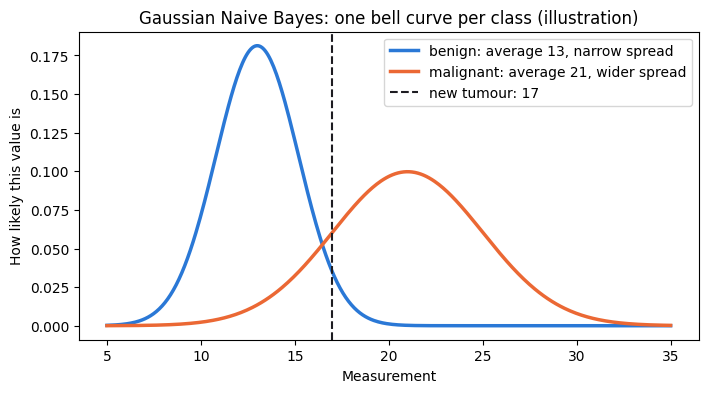

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(5, 35, 400)
def bell(x, mean, sd):
    return np.exp(-0.5 * ((x - mean) / sd) ** 2) / (sd * np.sqrt(2 * np.pi))

plt.figure(figsize=(8, 4))
plt.plot(x, bell(x, 13, 2.2), color="#2a78d6", lw=2.5, label="benign: average 13, narrow spread")
plt.plot(x, bell(x, 21, 4), color="#eb6834", lw=2.5, label="malignant: average 21, wider spread")
plt.axvline(17, color="#1D1C21", ls="--", lw=1.5, label="new tumour: 17")
plt.xlabel("Measurement")
plt.ylabel("How likely this value is")
plt.title("Gaussian Naive Bayes: one bell curve per class (illustration)")
plt.legend()
plt.show()

### Different kinds of Naive Bayes

- **GaussianNB**: for continuous measurements, like this notebook.
- **MultinomialNB**: for counts, such as how many times each word appears in an email. This is the
  classic spam filter.
- **BernoulliNB**: for yes/no features, such as whether each word appears at all.

## Setting up

First we import the libraries we need. Each line has a comment saying what it is for.

In [2]:
# pandas holds data in tables (DataFrames); numpy does the number crunching
import pandas as pd
import numpy as np
# matplotlib draws our charts
import matplotlib.pyplot as plt

# The dataset, and tools for splitting and scaling it
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Performance measures and chart helpers
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, RocCurveDisplay, roc_auc_score)
from sklearn.inspection import DecisionBoundaryDisplay

# The model for this notebook
from sklearn.naive_bayes import GaussianNB

# Chart settings and colours used throughout
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
BENIGN_COLOUR = "#2a78d6"      # blue
MALIGNANT_COLOUR = "#eb6834"   # orange
TRAIN_COLOUR = "#1D1C21"       # dark grey
CHECK_COLOUR = "#2a78d6"       # blue

## 2. The dataset

We use the **Breast Cancer Wisconsin** dataset, which comes built into scikit-learn, so there is
nothing to download. Each row is one breast tumour. The columns are measurements taken from a
microscope image of cells from the tumour, such as the radius of the cell nuclei, their texture
(how varied the grey levels are) and how many concave points (inward dents) their outlines have.

Our job is to predict whether each tumour is **malignant** (cancerous) or **benign** (not cancerous).
There are only two possible answers, so this is a **binary classification** problem.

In [3]:
# Load the data as a pandas DataFrame
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

print("Number of tumours (rows):", df.shape[0])
print("Number of columns:", df.shape[1])
df.head()

Number of tumours (rows): 569
Number of columns: 31


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


There are 569 tumours and 31 columns: 30 measurements, which are the **features** (the inputs), and
a column called `target`, which is the **label** (the answer we want to predict).

The 30 features are really 10 measurements, each recorded in three ways: the `mean` across the cells
in the image, the `error` (how much the values varied) and the `worst` (the average of the three
largest values).

## 3. Exploring the data

Before building any model it is worth looking at the data. We want to know how many examples there
are of each class and whether the features look useful.

### Fixing the label

In this dataset `target` is **0 for malignant and 1 for benign**, which is the opposite of what most
people would expect. scikit-learn treats the class labelled 1 as the "positive" class when it calculates
precision and recall, and we care most about finding malignant tumours. So we make a new, clearer
label column where **1 means malignant** and **0 means benign**.

malignant
benign (0)       357
malignant (1)    212
Name: count, dtype: int64


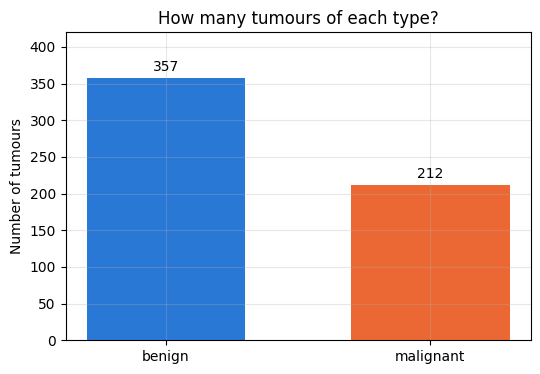

In [4]:
# New label: 1 = malignant, 0 = benign
df["malignant"] = (df["target"] == 0).astype(int)
df = df.drop(columns="target")

counts = df["malignant"].value_counts().sort_index()
print(counts.rename({0: "benign (0)", 1: "malignant (1)"}))

plt.figure(figsize=(6, 4))
bars = plt.bar(["benign", "malignant"], counts.values, color=[BENIGN_COLOUR, MALIGNANT_COLOUR], width=0.6)
plt.bar_label(bars, padding=3)
plt.ylabel("Number of tumours")
plt.title("How many tumours of each type?")
plt.ylim(0, 420)
plt.show()

There are 357 benign and 212 malignant tumours, so about 63% are benign. The classes are not
perfectly balanced. This gives us a useful **baseline**: a lazy "model" that always says benign would
be right about 63% of the time. Any real model has to do a lot better than that to be worth using.

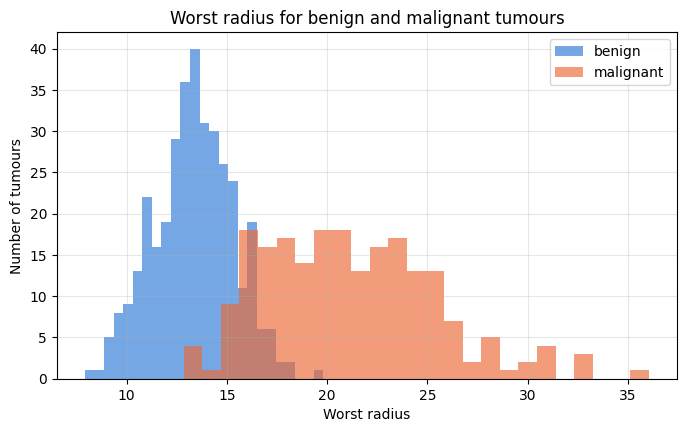

In [5]:
# Does one feature on its own separate the two classes?
plt.figure(figsize=(8, 4.5))
plt.hist(df.loc[df["malignant"] == 0, "worst radius"], bins=25, alpha=0.65,
         color=BENIGN_COLOUR, label="benign")
plt.hist(df.loc[df["malignant"] == 1, "worst radius"], bins=25, alpha=0.65,
         color=MALIGNANT_COLOUR, label="malignant")
plt.xlabel("Worst radius")
plt.ylabel("Number of tumours")
plt.title("Worst radius for benign and malignant tumours")
plt.legend()
plt.show()

Malignant tumours tend to have larger cells, but the two groups overlap in the middle. No single
measurement separates them perfectly, which is why we want a model that combines all 30.

## 4. Data pre-processing

Pre-processing means checking and preparing the data so that a model can learn from it properly.

### 4.1 Missing values and duplicates

In [6]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


This dataset has no missing values and no duplicated rows, which is unusual. With real-world data you
would normally need to deal with gaps, for example by removing incomplete rows or filling each gap
with the column's median value.

### 4.2 Separating the features (X) and the label (y)

By convention we call the inputs `X` and the answers `y`.

In [7]:
X = df.drop(columns="malignant")   # the 30 measurements
y = df["malignant"]                 # the answer: 1 = malignant, 0 = benign

print("X:", X.shape, "   y:", y.shape)

X: (569, 30)    y: (569,)


### 4.3 Do the features need scaling?

The features are measured on very different scales:

In [8]:
X[["mean radius", "mean area", "mean smoothness"]].describe().loc[["mean", "min", "max"]].round(3)

,mean radius,mean area,mean smoothness
mean,14.127,654.889,0.096
min,6.981,143.500,0.053
max,28.110,2501.000,0.163


`mean area` is in the hundreds, while `mean smoothness` is around 0.1. For many models that would be a
problem, but not for this one. Gaussian Naive Bayes treats each feature separately and learns that feature's own average and spread in its own units. Changing the units of a feature changes its average and spread in exactly the same way, so the predictions do not change.

So we will **not** scale the data in this notebook. (Scaling would do no harm, but it would not help
either.)

## 5. The train/test split

If we trained a model on every tumour and then tested it on the same tumours, it could score well just
by remembering them. That would tell us nothing about how it will perform on **new** patients.

So we split the data into two parts:

- the **training set**, which the model learns from, and
- the **test set**, which we hide away and only use at the end to check how well the model works on
  tumours it has never seen.

The settings we use:

- `test_size=0.25`: keep 25% of the tumours for testing.
- `stratify=y`: keep the same proportion of malignant tumours in both parts.
- `random_state=42`: the split is random, but fixing this number means you get the same split every
  time you run the notebook (and the same as everyone else in the class).

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print("Training set:", len(X_train), "tumours")
print("Test set:    ", len(X_test), "tumours")
print("Malignant in training set:", round(y_train.mean() * 100, 1), "%")
print("Malignant in test set:    ", round(y_test.mean() * 100, 1), "%")

Training set: 426 tumours
Test set:     143 tumours
Malignant in training set: 37.3 %
Malignant in test set:     37.1 %


Thanks to `stratify=y`, both sets contain the same share of malignant tumours (about 37%).

This model does not need scaling, so we can use the training and test sets exactly as they are.
To keep the code the same shape as the other notebooks, we just give them new names.

In [10]:
X_train_ready = X_train
X_test_ready = X_test

## 6. Fitting (training) the model


We create the model and call `fit`. Training is very fast: the model just calculates, for each class,
the proportion of tumours in it (the prior) and the average and variance of every feature.

In [11]:
model = GaussianNB()
model.fit(X_train_ready, y_train)

print("Prior probabilities learned from the training set:")
print(f"  benign:    {model.class_prior_[0]:.3f}")
print(f"  malignant: {model.class_prior_[1]:.3f}")

Prior probabilities learned from the training set:
  benign:    0.627
  malignant: 0.373


Here are the averages the model learned for a few features. These, with the spreads, are everything the model knows:

In [12]:
learned_means = pd.DataFrame(model.theta_, columns=X.columns, index=["benign", "malignant"])
learned_means[["mean radius", "mean texture", "worst radius", "worst concave points"]].round(3)

,mean radius,mean texture,worst radius,worst concave points
benign,12.166,18.101,13.423,0.076
malignant,17.530,21.581,21.308,0.182


Malignant tumours have larger averages for all four of these measurements.

## 7. Making predictions

With the model trained, we ask it to predict the label for every tumour in the **test set**. These are
tumours it has never seen.

As well as a yes/no answer, `predict_proba` gives the model's estimated **probability** that each
tumour is malignant. By default, the model predicts malignant when that probability is 0.5 or more.

In [13]:
y_pred = model.predict(X_test_ready)
y_prob = model.predict_proba(X_test_ready)[:, 1]   # probability of malignant

# Compare the first 10 predictions with the real answers
first_ten = pd.DataFrame({
    "actual": y_test.values[:10],
    "predicted": y_pred[:10],
    "probability of malignant": y_prob[:10].round(3),
})
first_ten["correct?"] = np.where(first_ten["actual"] == first_ten["predicted"], "yes", "NO")
first_ten

,actual,predicted,probability of malignant,correct?
0,1,1,1.000,yes
1,0,0,0.000,yes
2,1,1,1.000,yes
3,0,0,0.000,yes
4,0,0,0.013,yes
5,0,0,0.000,yes
6,0,0,0.000,yes
7,0,0,0.000,yes
8,0,0,0.000,yes
9,0,0,0.000,yes


## 8. Measuring performance

There are several ways to measure how good a classifier is. Each one answers a slightly different
question, and for a medical problem like this the differences really matter.

### 8.1 Accuracy

Accuracy is the simplest measure: **what fraction of predictions were correct?**

In [14]:
accuracy = accuracy_score(y_test, y_pred)
baseline = (y_test == 0).mean()   # always guessing "benign"

print(f"Accuracy of the model:          {accuracy:.3f}")
print(f"Accuracy of always saying benign: {baseline:.3f}")

Accuracy of the model:          0.944
Accuracy of always saying benign: 0.629


The model is well above the baseline. But accuracy on its own hides an important detail: **what kind
of mistakes** did the model make?

### 8.2 The confusion matrix

A confusion matrix sorts every prediction into one of four boxes:

| | Model says benign | Model says malignant |
|---|---|---|
| **Really benign** | True negative (TN): correct | False positive (FP): a false alarm |
| **Really malignant** | False negative (FN): a missed cancer | True positive (TP): correct |

The two kinds of mistake are not equally bad. A false alarm means a worried patient and an extra test.
A false negative means a cancer is missed.

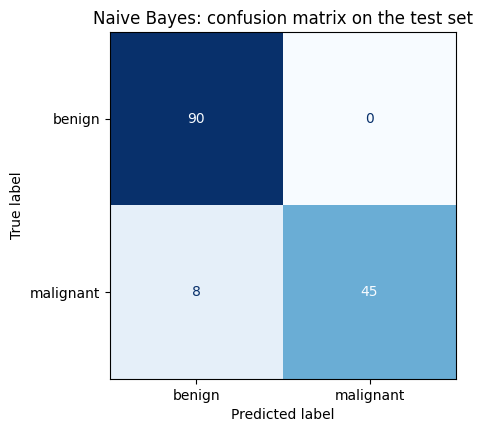

True negatives  (benign, correctly identified):    90
False positives (benign, wrongly called malignant): 0
False negatives (malignant, missed):               8
True positives  (malignant, correctly found):      45


In [15]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["benign", "malignant"], cmap="Blues", colorbar=False
)
plt.title("Naive Bayes: confusion matrix on the test set")
plt.grid(False)
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"True negatives  (benign, correctly identified):    {tn}")
print(f"False positives (benign, wrongly called malignant): {fp}")
print(f"False negatives (malignant, missed):               {fn}")
print(f"True positives  (malignant, correctly found):      {tp}")

### 8.3 Precision, recall and F1

These three measures focus on the malignant class:

- **Precision** = TP / (TP + FP). Of all the tumours the model *called* malignant, what fraction really
  were? High precision means few false alarms.
- **Recall** = TP / (TP + FN). Of all the tumours that *really were* malignant, what fraction did the
  model find? High recall means few missed cancers. (Recall is also called **sensitivity**.)
- **F1 score** combines precision and recall into one number. It is only high when both are high.

For cancer screening, recall is usually the most important of these, because missing a cancer is the
worst outcome.

In [16]:
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1 score:  {f1_score(y_test, y_pred):.3f}")

Precision: 1.000
Recall:    0.849
F1 score:  0.918


`classification_report` prints all of these at once, for **both** classes. The `support` column is the
number of test tumours in each class.

In [17]:
print(classification_report(y_test, y_pred, target_names=["benign", "malignant"]))

              precision    recall  f1-score   support

      benign       0.92      1.00      0.96        90
   malignant       1.00      0.85      0.92        53

    accuracy                           0.94       143
   macro avg       0.96      0.92      0.94       143
weighted avg       0.95      0.94      0.94       143



### 8.4 The ROC curve and AUC

The model's decision depends on the 0.5 probability threshold. If we lowered the threshold, it would
catch more malignant tumours but raise more false alarms; if we raised it, the opposite.

A **ROC curve** shows this trade-off across every possible threshold. It plots the **true positive
rate** (recall) against the **false positive rate** (the fraction of benign tumours wrongly flagged).
A perfect model goes straight up the left side and along the top. A model that guesses at random
follows the dashed diagonal line.

The **AUC** (area under the curve) sums this up in one number, from 0.5 (guessing) to 1.0 (perfect).

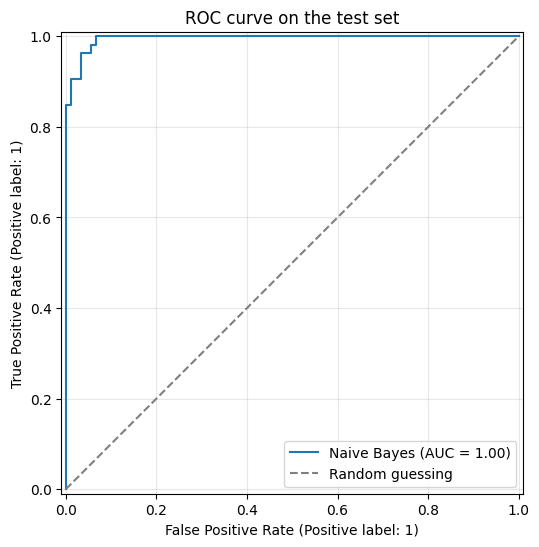

AUC: 0.995


In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test, y_prob, name="Naive Bayes", ax=ax)
ax.plot([0, 1], [0, 1], "--", color="grey", label="Random guessing")
ax.set_title("ROC curve on the test set")
ax.legend(loc="lower right")
plt.show()

print(f"AUC: {roc_auc_score(y_test, y_prob):.3f}")

## 9. Looking inside the model

### The bell curves the model actually learned

Here are the real curves the model learned for `worst radius`, drawn over the training data.

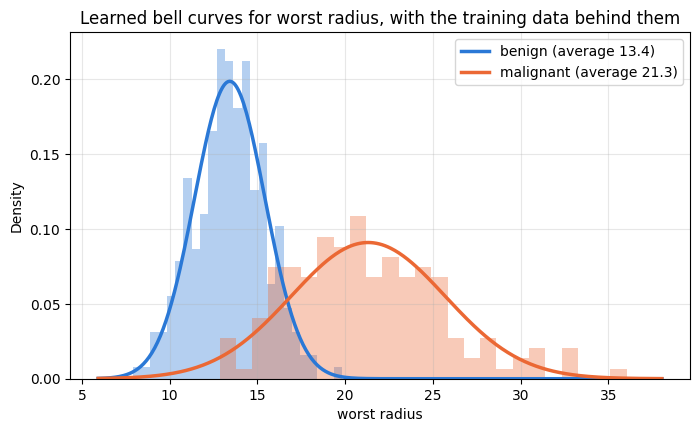

In [19]:
feature = "worst radius"
col = list(X.columns).index(feature)
x = np.linspace(X_train[feature].min() - 2, X_train[feature].max() + 2, 400)

plt.figure(figsize=(8, 4.5))
for cls, colour, name in [(0, BENIGN_COLOUR, "benign"), (1, MALIGNANT_COLOUR, "malignant")]:
    mean, var = model.theta_[cls, col], model.var_[cls, col]
    curve = np.exp(-0.5 * (x - mean) ** 2 / var) / np.sqrt(2 * np.pi * var)
    plt.hist(X_train.loc[y_train == cls, feature], bins=25, density=True, alpha=0.35, color=colour)
    plt.plot(x, curve, color=colour, lw=2.5, label=f"{name} (average {mean:.1f})")
plt.xlabel(feature)
plt.ylabel("Density")
plt.title("Learned bell curves for worst radius, with the training data behind them")
plt.legend()
plt.show()

The bell curves are a reasonable, if not perfect, summary of the real data. The model does this for all
30 features and combines the evidence.

### Naive Bayes is often overconfident

Because it multiplies evidence from 30 features as if they were independent, and many of our features
say nearly the same thing, Naive Bayes tends to double-count evidence. The result is probabilities that
are pushed very close to 0 or 1.

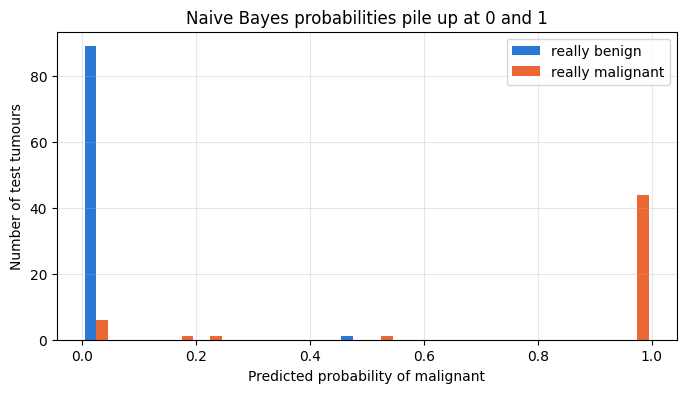

In [20]:
plt.figure(figsize=(8, 4))
plt.hist([y_prob[y_test == 0], y_prob[y_test == 1]], bins=20,
         color=[BENIGN_COLOUR, MALIGNANT_COLOUR], label=["really benign", "really malignant"])
plt.xlabel("Predicted probability of malignant")
plt.ylabel("Number of test tumours")
plt.title("Naive Bayes probabilities pile up at 0 and 1")
plt.legend()
plt.show()

Nearly every tumour gets a probability close to 0 or close to 1, even the ones the model gets wrong.
So Naive Bayes is useful for **ranking** and **classifying**, but its probabilities should not be taken
literally.

### Checking that scaling makes no difference

In [21]:
scaler = StandardScaler().fit(X_train)
scaled_model = GaussianNB().fit(scaler.transform(X_train), y_train)

print(f"Accuracy on original data: {model.score(X_test, y_test):.3f}")
print(f"Accuracy on scaled data:   {scaled_model.score(scaler.transform(X_test), y_test):.3f}")

Accuracy on original data: 0.944
Accuracy on scaled data:   0.944


## 10. Seeing the decision boundary

With 30 features we cannot draw what the model has learned. But if we train the same kind of model on
just **two** features, we can plot every tumour on a flat chart and colour in the regions where the
model would predict benign or malignant. The line where the colours meet is the **decision boundary**.

We use `mean radius` and `mean texture`. These two features overlap quite a lot, which makes the
boundary more interesting to look at. This two-feature model is only for the picture; our real model
still uses all 30 features.

Gaussian Naive Bayes produces smooth, curved boundaries, because each class is described by its own
bell-shaped cloud. On the right, we tell the model to ignore how common each class is and assume the
two are equally likely (`priors=[0.5, 0.5]`). Compare the two boundaries closely.

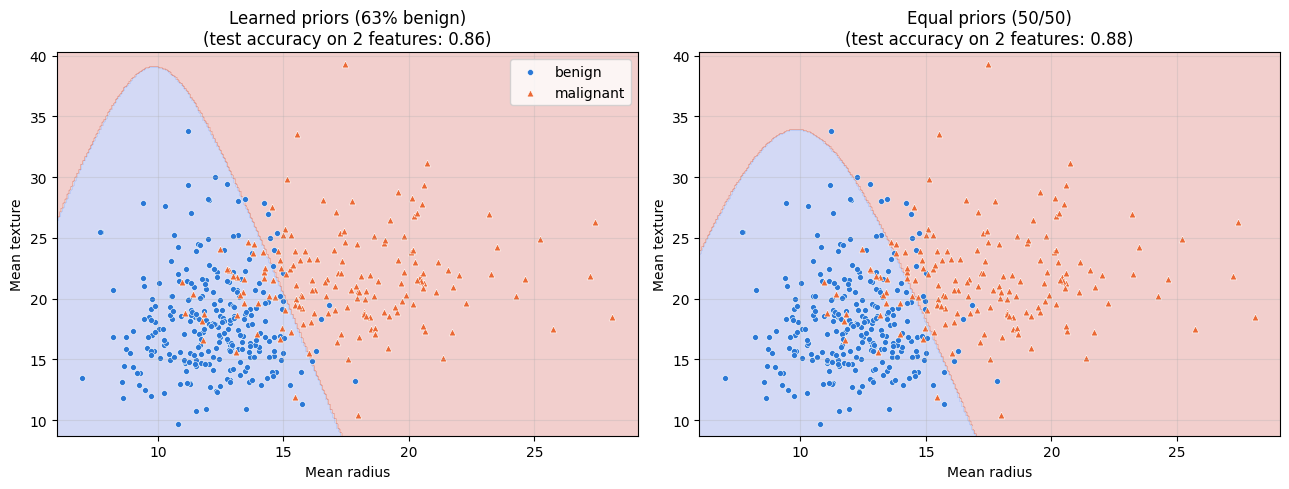

In [22]:
two = ["mean radius", "mean texture"]
X_two = X_train[two]

def draw_boundary(model, ax, title):
    """Fit a model on two features and colour in its predictions."""
    model.fit(X_two, y_train)
    DecisionBoundaryDisplay.from_estimator(
        model, X_two, response_method="predict", ax=ax, alpha=0.25,
        cmap="coolwarm", grid_resolution=300, xlabel="Mean radius", ylabel="Mean texture"
    )
    benign = y_train == 0
    ax.scatter(X_two.loc[benign, two[0]], X_two.loc[benign, two[1]], s=18,
               color=BENIGN_COLOUR, edgecolor="white", linewidth=0.4, label="benign")
    ax.scatter(X_two.loc[~benign, two[0]], X_two.loc[~benign, two[1]], s=24, marker="^",
               color=MALIGNANT_COLOUR, edgecolor="white", linewidth=0.4, label="malignant")
    acc = model.score(X_test[two], y_test)
    ax.set_title(f"{title}\n(test accuracy on 2 features: {acc:.2f})")


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
draw_boundary(GaussianNB(), axes[0], "Learned priors (63% benign)")
draw_boundary(GaussianNB(priors=[0.5, 0.5]), axes[1], "Equal priors (50/50)")
axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()

## 11. Changing the parameters

Every model has settings that we choose before training. These are called **hyperparameters**.
Changing them changes how simple or complex the model is.

### Choosing settings fairly

We must **not** use the test set to choose settings. If we tried lots of settings and kept whichever
did best on the test set, the test set would no longer be a fair check.

Instead we use **cross-validation** on the training set. The training data is split into 5 parts. The
model trains on 4 parts and is checked on the 5th, and this is repeated so that each part gets a turn.
The average of the 5 scores tells us how well a setting works on data the model did not train on.

The function below tries a list of values for one setting and plots two lines:

- **training accuracy**: how well the model does on the data it learned from;
- **cross-validated accuracy**: our fair estimate of how it will do on new data.

A big gap between the two lines is a sign of **overfitting**: the model has memorised the training data.
When both lines are low, the model is **underfitting**: it is too simple to capture the pattern.

Naive Bayes has very few settings, which is one of its attractions. We look at the two that exist.

### 1. The priors

By default the priors come from the training data (about 63% benign). If we lower the prior for benign,
the model needs less evidence before calling a tumour malignant. We measure the effect using
cross-validated **recall**, because recall is about finding malignant tumours.

In [23]:
def try_settings(make_model, values, setting_name, X_data, log_scale=False, tolerance=0):
    """Try each value of one setting; plot training vs cross-validated accuracy.

    The values must be listed from simplest to most complex. The chosen value is the simplest
    one whose cross-validated accuracy is within `tolerance` of the best.
    """
    train_scores, cv_scores = [], []
    for value in values:
        m = make_model(value)
        cv_scores.append(cross_val_score(m, X_data, y_train, cv=5).mean())
        train_scores.append(m.fit(X_data, y_train).score(X_data, y_train))

    plt.plot(values, train_scores, "o-", color=TRAIN_COLOUR, label="Training accuracy")
    plt.plot(values, cv_scores, "s-", color=CHECK_COLOUR, label="Cross-validated accuracy")
    if log_scale:
        plt.xscale("log")
    plt.xlabel(setting_name)
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    table = pd.DataFrame({setting_name: values,
                          "training accuracy": np.round(train_scores, 3),
                          "cross-validated accuracy": np.round(cv_scores, 3)})
    top = max(cv_scores)
    best = next(v for v, s in zip(values, cv_scores) if s >= top - tolerance - 1e-9)
    return table, best

In [24]:
for priors in [None, [0.5, 0.5], [0.3, 0.7]]:
    nb_model = GaussianNB(priors=priors)
    recall = cross_val_score(nb_model, X_train_ready, y_train, cv=5, scoring="recall").mean()
    acc = cross_val_score(nb_model, X_train_ready, y_train, cv=5).mean()
    label = "learned from data" if priors is None else f"benign {priors[0]}, malignant {priors[1]}"
    print(f"Priors {label:>30}: recall = {recall:.3f}, accuracy = {acc:.3f}")

Priors              learned from data: recall = 0.899, accuracy = 0.944
Priors      benign 0.5, malignant 0.5: recall = 0.899, accuracy = 0.941
Priors      benign 0.3, malignant 0.7: recall = 0.899, accuracy = 0.939


Perhaps surprisingly, changing the priors makes almost no difference here. The reason is the
overconfidence we saw in section 9: with 30 features, the evidence from the measurements is so strong
that the probabilities are nearly always close to 0 or 1, and nudging the prior is not enough to change
many decisions. With fewer features, or a much rarer class, the priors matter a lot more. In principle,
shifting the prior towards malignant is a way of telling the model that missing a cancer is the worse mistake.

### 2. var_smoothing

`var_smoothing` adds a small amount to every variance, to stop the model breaking when a feature has
almost no spread. Larger values make every bell curve wider and the model more cautious (simpler). We try
values from large to small.

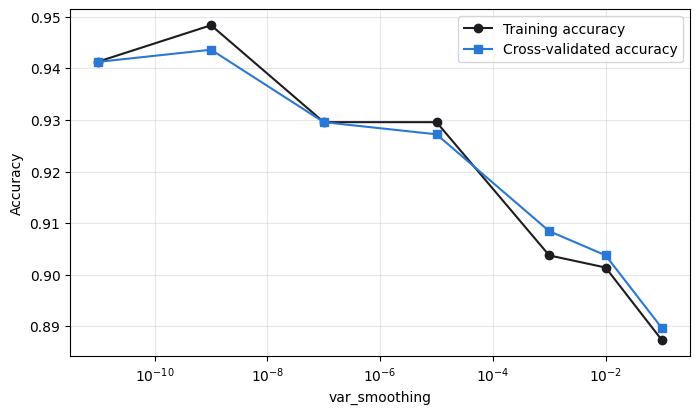

Chosen var_smoothing: 1e-09


,var_smoothing,training accuracy,cross-validated accuracy
0,1.000000e-01,0.887,0.890
1,1.000000e-02,0.901,0.904
2,1.000000e-03,0.904,0.908
3,1.000000e-05,0.930,0.927
4,1.000000e-07,0.930,0.930
5,1.000000e-09,0.948,0.944
6,1.000000e-11,0.941,0.941


In [25]:
smoothing_values = [1e-1, 1e-2, 1e-3, 1e-5, 1e-7, 1e-9, 1e-11]
table, best_smoothing = try_settings(lambda v: GaussianNB(var_smoothing=v),
                                     smoothing_values, "var_smoothing", X_train_ready, log_scale=True)
print("Chosen var_smoothing:", best_smoothing)
table

**What to notice:** unlike the other models in this module, the training and cross-validated lines stay
close together. Naive Bayes is a simple model that rarely overfits. Very large smoothing values blur the
bell curves too much and accuracy falls.

### Retraining with the chosen setting

Now we train a fresh model with the chosen setting on the whole training set, and check it **once** on
the test set. We compare it with the default model from earlier.

In [26]:
tuned = GaussianNB(var_smoothing=best_smoothing)
tuned.fit(X_train_ready, y_train)
tuned_pred = tuned.predict(X_test_ready)

summary = pd.DataFrame({
    "default model": [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred),
                      recall_score(y_test, y_pred), f1_score(y_test, y_pred)],
    "tuned model":   [accuracy_score(y_test, tuned_pred), precision_score(y_test, tuned_pred),
                      recall_score(y_test, tuned_pred), f1_score(y_test, tuned_pred)],
}, index=["accuracy", "precision", "recall", "F1"]).round(3)
summary

,default model,tuned model
accuracy,0.944,0.944
precision,1.000,1.000
recall,0.849,0.849
F1,0.918,0.918


Tuning does not always change the result. Sometimes the default settings are already a good choice, or
the chosen setting happens to make the same predictions on these 143 test tumours. Occasionally a tuned
model even does slightly worse on the test set, because cross-validation gives a fair **estimate**, not a
guarantee. What matters is that the setting was chosen without looking at the test set, so the test
score is an honest measure of how the model is likely to perform on new patients.

## 12. Discussion

### Strengths

- Extremely fast to train and to predict, even with millions of examples or thousands of features.
- Works well with small amounts of training data.
- Very few settings to tune, and it rarely overfits.
- Excellent for text (with MultinomialNB), which is why it became the classic spam filter.


### Limitations

- The independence assumption is almost never true, so its probabilities are often overconfident.
- Usually a little less accurate than more flexible models on numeric data like ours.
- Gaussian NB assumes bell-shaped features; strongly skewed features can mislead it.


### Where it is used

- Spam filtering and sorting emails into folders.
- Classifying documents or news articles by topic.
- Sentiment analysis (positive or negative reviews).
- A quick baseline: if a complex model cannot beat Naive Bayes, something is wrong.


### When should you choose it?

Choose Naive Bayes when you need something fast and simple, when you have little data, or when you are
working with text. It is also a sensible first model to compare others against.


## 13. Summary of the process

Every supervised learning project in this module follows the same steps you have just worked through:

1. **Understand the problem and the data**: what are the features, what is the label?
2. **Explore** the data: class balance, useful features, anything odd.
3. **Pre-process**: deal with missing values, fix labels, and scale if the model needs it.
4. **Split** into training and test sets, with scaling learned from the training set only.
5. **Fit** the model to the training data.
6. **Predict** on the test set.
7. **Measure** performance with more than one metric, thinking about which mistakes matter most.
8. **Tune** the settings with cross-validation, then check the final model once on the test set.

## 14. Your turn


1. Change the priors in section 6 to `GaussianNB(priors=[0.1, 0.9])`. Does the confusion matrix change? Explain why the effect is so small.
2. Draw the learned bell curves (section 9) for `mean texture` instead of `worst radius`. Is it a more or less useful feature?
3. Train the model using only the 10 `mean` features (`X_train[X.columns[:10]]`). Does accuracy go up or down, and why might that be?
4. Look at the probability histogram. Find a test tumour the model got wrong and check its predicted probability. How confident was the model?
5. In your own words, explain what the "naive" assumption is, using two features from this dataset as an example.